# boneseg from Python

The web app is the easiest way to use boneseg, but every step is also a plain Python function. This notebook segments the synthetic demo stack from a few clicks, measures it, runs the whole stack, computes bone histomorphometry and trains a small model from a corrected slice.

Run it from the repository root with the packages from `requirements.txt` installed. It uses DINOv2 Small, whose weights (about 85 MB) download on first use. Set `BACKBONE = "classic"` for a quick run without a download.

In [1]:
import sys, tempfile
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import numpy as np
import scipy.ndimage as ndi
import matplotlib.pyplot as plt

from boneseg import io as bio, metrics, quantify, histo
from boneseg.backbone import get_backbone
from boneseg.demo import write_demo_tiff
from boneseg.pipeline import StackRequest, run_stack
from boneseg.segment import SegmentationSettings, embed_image, prototypes, segment

BACKBONE = "dinov2_s14"
work = Path(tempfile.mkdtemp())

## 1. Load a stack

`load_volume` opens Imaris, TIFF, PNG/JPG and NumPy files as a (channel, z, y, x) volume and reads planes on demand.

In [2]:
vol = bio.load_volume(write_demo_tiff(work / "demo.tif"))
print(vol.info())
z, cells_ch, bone_ch, ref_ch = 6, 1, 0, 2
img = bio.normalize_plane(vol.get_plane(cells_ch, z))
ref = vol.get_plane(ref_ch, z) > 0

{'name': 'demo.tif', 'n_channels': 3, 'n_z': 12, 'height': 384, 'width': 512, 'voxel_um': [2.0, 0.65, 0.65], 'voxel_size_known': True, 'channel_names': ['Channel 0', 'Channel 1', 'Channel 2'], 'dtype': 'uint16'}


## 2. Segment from clicks

Clicks are (y, x) pixel positions. Here they come from the demo's expert mask: three cell centres and four background spots.

threshold 0.572 (clicks), Dice against the expert mask 0.883


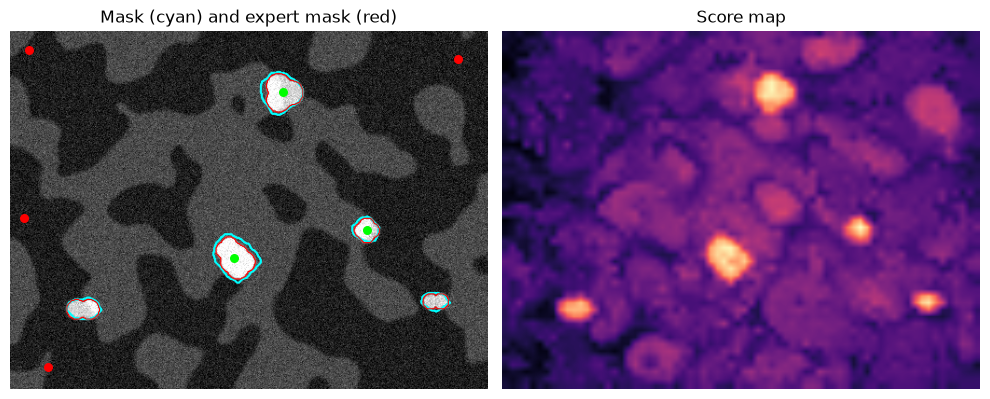

In [3]:
lab, n = ndi.label(ref)
pos = [tuple(int(v) for v in c) for c in ndi.center_of_mass(ref, lab, range(1, n + 1))[:3]]
neg = [(20, 20), (360, 40), (30, 480), (200, 15)]

settings = SegmentationSettings(backbone=BACKBONE)
emb = embed_image(get_backbone(BACKBONE), img, settings)
res = segment(emb, pos, neg, settings, vol.pixel_um)
print(f"threshold {res.threshold:.3f} ({res.threshold_source}), Dice against the expert mask {metrics.dice(res.mask, ref):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(img, cmap="gray"); ax[0].contour(res.mask, [0.5], colors="cyan"); ax[0].contour(ref, [0.5], colors="red", linewidths=0.8)
ax[0].scatter([p[1] for p in pos], [p[0] for p in pos], c="lime", s=30); ax[0].scatter([p[1] for p in neg], [p[0] for p in neg], c="red", s=30)
ax[0].set_title("Mask (cyan) and expert mask (red)"); ax[1].imshow(res.heat, cmap="magma"); ax[1].set_title("Score map")
for a in ax: a.axis("off")
plt.tight_layout()

## 3. Measure

All measurements use the pixel size from the file.

In [4]:
summary = quantify.summarize_mask(res.mask, img, vol.pixel_um)
{k: round(v, 3) for k, v in summary.items()}

{'area_um2': 2004.763,
 'area_fraction': 0.024,
 'image_area_um2': 83066.88,
 'n_objects': 5,
 'objects_per_mm2': 60.192,
 'mean_object_area_um2': 400.952,
 'median_object_area_um2': 266.598,
 'largest_object_area_um2': 716.56,
 'mean_intensity_inside': 0.781,
 'mean_intensity_outside': 0.197,
 'contrast_ratio': 3.968}

In [5]:
quantify.object_table(res.mask, img, vol.pixel_um).round(2).head()

,label,area_um2,centroid_y_um,centroid_x_um,perimeter_um,eccentricity,solidity,major_axis_um,minor_axis_um,equivalent_diameter_um,mean_intensity
0,3,716.56,157.70,156.97,103.50,0.62,0.96,34.35,27.01,30.21,0.78
1,1,613.05,42.66,188.38,94.00,0.22,0.96,28.58,27.85,27.94,0.77
2,5,266.60,193.27,51.21,62.83,0.78,0.96,23.30,14.66,18.42,0.80
3,2,233.64,138.16,247.83,57.25,0.49,0.96,18.59,16.20,17.25,0.82
4,4,174.92,188.15,295.71,50.84,0.74,0.94,18.33,12.33,14.92,0.71


## 4. Run the whole stack

The prototypes and the threshold from the clicked slice carry over to every slice. Scores are standardized per slice, so the threshold stays meaningful when deeper slices get dimmer.

In [6]:
pos_t, neg_t = prototypes(emb, pos), prototypes(emb, neg)
bb = get_backbone(BACKBONE)
planes = {zz: bio.normalize_plane(vol.get_plane(cells_ch, zz)) for zz in range(vol.n_z)}
out = run_stack(StackRequest(z_list=list(range(vol.n_z)), ref_z=z), pos_t, neg_t, settings, res.raw_threshold,
                get_embedding=lambda zz: embed_image(bb, planes[zz], settings), get_image=planes.__getitem__,
                get_reference=lambda zz: vol.get_plane(ref_ch, zz) > 0, voxel_um=vol.voxel_um, out_dir=work)
s = out["summary"]
print(f"{s['n_slices']} slices, volume {s['volume_um3']:.0f} µm³, {s['n_objects_3d']} objects in 3D, mean Dice {s['mean_dice_vs_reference']:.3f}")
print("Files:", sorted(p.name for p in work.glob("*.*")))

12 slices, volume 54960 µm³, 21 objects in 3D, mean Dice 0.892
Files: ['demo.tif', 'masks.tif', 'objects_3d.csv', 'slices.csv', 'summary.json']


## 5. Bone histomorphometry

Segment the bone matrix on channel 0 with a few clicks of its own, then combine it with the cell mask.

In [7]:
bone_img = bio.normalize_plane(vol.get_plane(bone_ch, z))
smooth = ndi.gaussian_filter(bone_img, 3)
rng = np.random.default_rng(0)
hi, lo = np.argwhere(smooth > np.percentile(smooth, 85)), np.argwhere(smooth < np.percentile(smooth, 15))
bone_pos = [tuple(p) for p in hi[rng.choice(len(hi), 6, replace=False)]]
bone_neg = [tuple(p) for p in lo[rng.choice(len(lo), 6, replace=False)]]
bone = segment(embed_image(bb, bone_img, settings), bone_pos, bone_neg, settings, vol.pixel_um).mask

hm, cells_table = histo.histomorphometry(bone, res.mask, vol.pixel_um, contact_um=3.0)
{k: round(v, 3) if isinstance(v, float) else v for k, v in hm.items()}

{'T.Ar_mm2': np.float64(0.083),
 'B.Ar_mm2': 0.029,
 'B.Ar/T.Ar_%': np.float64(34.991),
 'B.Pm_mm': 4.114,
 'Oc.Pm/B.Pm_%': 3.37,
 'Oc.Pm_mm': 0.139,
 'N.Oc': 5,
 'N.Oc/B.Pm_per_mm': 1.215,
 'N.Oc/T.Ar_per_mm2': np.float64(60.192),
 'cells_total': 5,
 'cells_on_bone_%': 100.0,
 'median_distance_to_bone_um': 0.0,
 'contact_um': 3.0}

## 6. Learn from a corrected slice

In the app you would correct a mask with the brush. Here the expert mask of two slices stands in for the corrections, and the learned model segments a slice it has not seen.

In [8]:
from boneseg.head import segment_with_head, train_head

train_z = [3, 9]
samples = [(embed_image(bb, planes[zz], settings), vol.get_plane(ref_ch, zz) > 0) for zz in train_z]
head = train_head(samples, settings, [(cells_ch, zz) for zz in train_z], pixel_um=vol.pixel_um)
learned = segment_with_head(head, emb, settings, vol.pixel_um)
print(f"{head.kind} head, cross-validated Dice {head.cv[head.cv['chosen']]['mean_dice']:.3f}, "
      f"Dice on slice {z}: learned {metrics.dice(learned.mask, ref):.3f} vs clicks {metrics.dice(res.mask, ref):.3f}")

mlp head, cross-validated Dice 0.925, Dice on slice 6: learned 0.913 vs clicks 0.883


## 7. Your own files

Swap the demo for your own file, for example `bio.load_volume("data/liudata/10-26-40_6_Blaze_crop2 quantified.ims")`, pick the channel, and click positions from Napari, Fiji or the web app. For many files at once, save a profile in the app and use `python -m boneseg batch`.